# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 10,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 0.5,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'T_crossover_ratio': 0.1,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     #'target_set': [0.0,1.0,1.0,0.0],
     'target_set': [-2,+2,+2,-2],
     #'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'input_set':[[-2,-2],[-2,+2],[+2,-2],[+2,+2]],
     'ff_iter': 20,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 200,
     'N_sol': 100}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean loss: 8.330466601269565
Mean target distance: 8.396008231625682
Parents indexes: [[16  5]
 [ 0  7]
 [40  0]
 [39 74]
 [35  3]
 [ 1  0]
 [ 5  7]
 [21 31]
 [35  0]
 [47  0]
 [ 6 26]
 [ 9  5]
 [10 12]
 [20  0]
 [ 1 38]
 [ 0 16]
 [ 0  7]
 [12  0]
 [ 7  0]
 [ 1  5]
 [ 0 80]
 [28  0]
 [89 76]
 [ 3 39]
 [ 7  0]
 [ 7  2]
 [ 1 16]
 [ 0  1]
 [ 2  0]
 [ 0  1]
 [ 0  6]
 [ 0 15]
 [ 0 49]
 [ 0  6]
 [ 1  0]
 [24  1]
 [56  0]
 [ 6  5]
 [ 0  9]
 [ 0  5]]
Selection Probabilities: [3.09134766e-01 9.21390083e-02 6.08261604e-02 4.99630470e-02
 3.78540045e-02 3.72085030e-02 2.32593012e-02 2.31230022e-02
 1.97044562e-02 1.83248858e-02 1.50682959e-02 1.27278844e-02
 1.19840630e-02 1.07512331e-02 1.02063280e-02 9.86831660e-03
 9.81219269e-03 9.78269440e-03 9.51433149e-03 9.13945179e-03
 8.25140042e-03 8.07519080e-03 7.61074274e-03 7.07755442e-03
 6.66165477e-03 6.57798776e-03 6.48293822e-03 6.40235384e-03
 6.34344019e-03 5.68434068e-03 5.40392060e-03 5.32752943e-03
 4.94836395e-03 4.806689

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 80


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-2, -2] -> Output: 1.1661960082247957
Target distance:3.1661960082247957
Link cost:0.011376544623606908
Input: [-2, 2] -> Output: 1.1661960082247957
Target distance:0.8338039917752043
Link cost:0.011376544623606908
Input: [2, -2] -> Output: 1.1661960082247957
Target distance:0.8338039917752043
Link cost:0.011376544623606908
Input: [2, 2] -> Output: 1.1661960082247957
Target distance:3.1661960082247957
Link cost:0.011376544623606908
loss:2.0
Solution #1
Input: [-2, -2] -> Output: 0.613477515538365
Target distance:2.613477515538365
Link cost:0.010482966418503131
Input: [-2, 2] -> Output: 0.613477515538365
Target distance:1.386522484461635
Link cost:0.010482966418503131
Input: [2, -2] -> Output: 0.613477515538365
Target distance:1.386522484461635
Link cost:0.010482966418503131
Input: [2, 2] -> Output: 0.613477515538365
Target distance:2.613477515538365
Link cost:0.010482966418503131
loss:2.0
Solution #2
Input: [-2, -2] -> Output: 1.083194355625291
Target distance:3.083

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses) < 100)}')

Mean final loss: 1.0


In [7]:
s = []
for _ in range(20):
    sol = m.generate(par)
    s.append(sol)

s = sorted(s, key=lambda sol: sol.loss)

loss = np.array([sol.loss for sol in s]) 
prob = np.exp(loss) / np.sum(np.exp(loss))
prob_inv = (1/prob)/np.sum(1/prob)
prob = np.exp(-loss) / np.sum(np.exp(-loss))

print(f'loss:{loss}')
print(f'prob:{prob}')
print(f'inv_prob:{prob_inv}')

loss:[ 7.10691034  7.44823848  7.92018629  7.92371712  8.09825769  8.14799283
  9.          9.          9.13143745  9.2914524   9.49324145 10.
 10.         10.20540547 10.91067655 10.95499199 11.         11.
 11.         12.        ]
prob:[0.23662142 0.16819656 0.10491867 0.10454888 0.08780462 0.08354446
 0.03563655 0.03563655 0.03124734 0.02662683 0.02176124 0.01310995
 0.01310995 0.01067566 0.00527351 0.00504491 0.00482288 0.00482288
 0.00482288 0.00177424]
inv_prob:[0.23662142 0.16819656 0.10491867 0.10454888 0.08780462 0.08354446
 0.03563655 0.03563655 0.03124734 0.02662683 0.02176124 0.01310995
 0.01310995 0.01067566 0.00527351 0.00504491 0.00482288 0.00482288
 0.00482288 0.00177424]


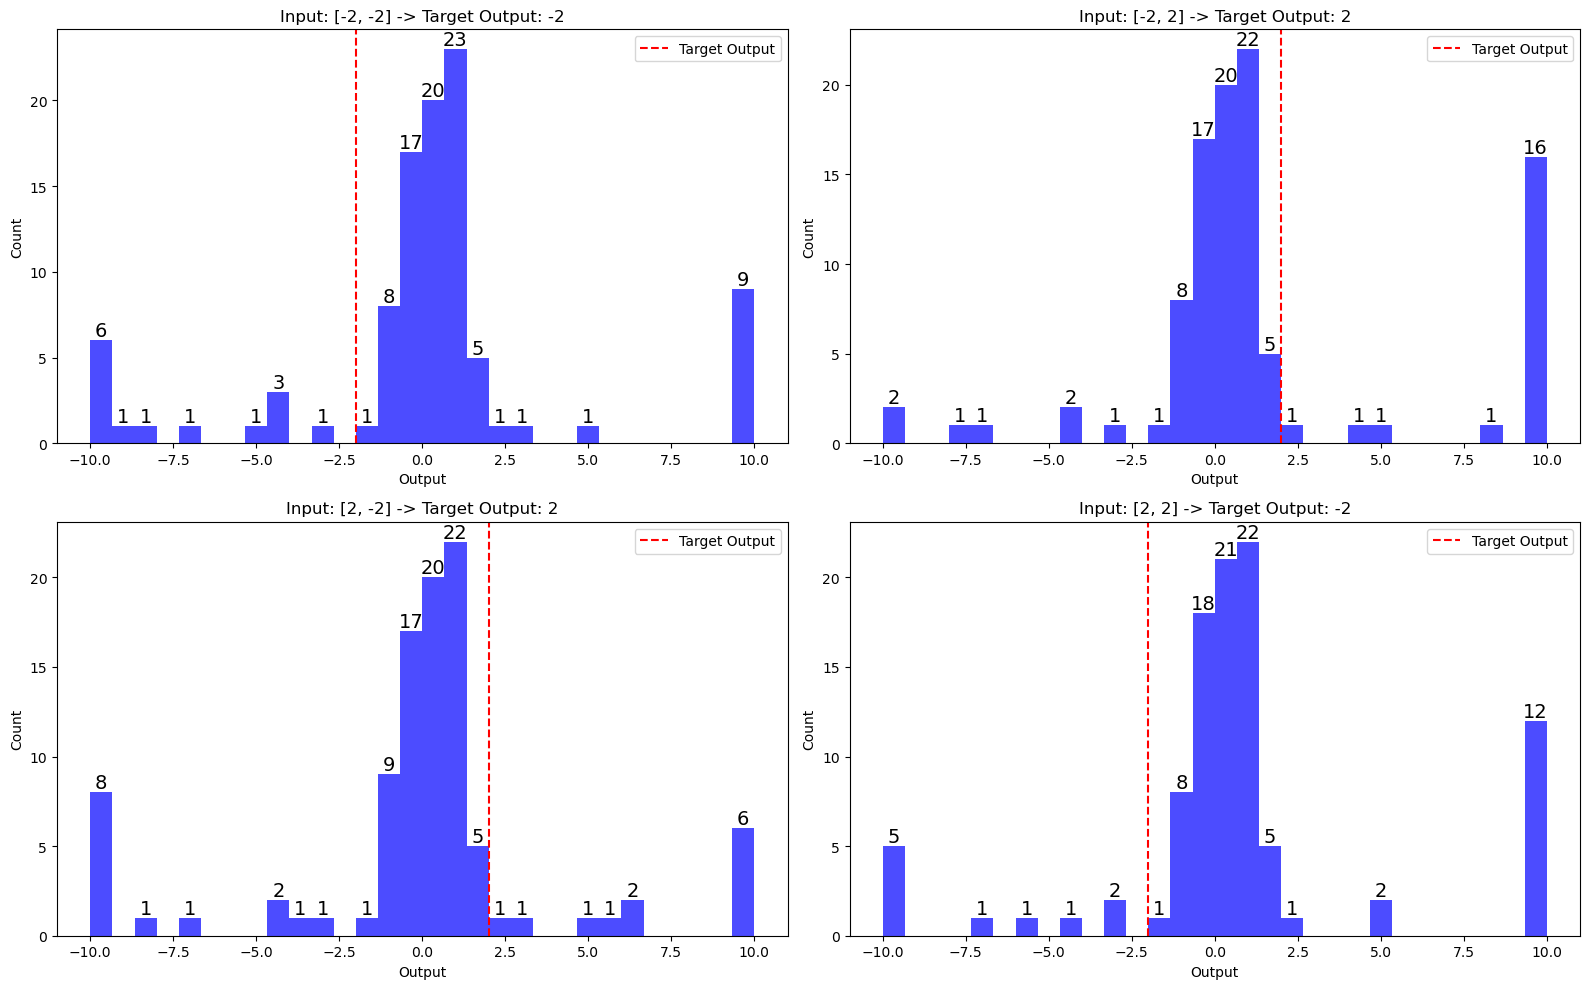

In [8]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
print(f'Vertex numbers of inputs: 0,{(par['L'] - 1) * par['L']-1}')
print(f'Vertex numbers of the output: {par['L']**2-1}')

Vertex numbers of inputs: 0,89
Vertex numbers of the output: 99


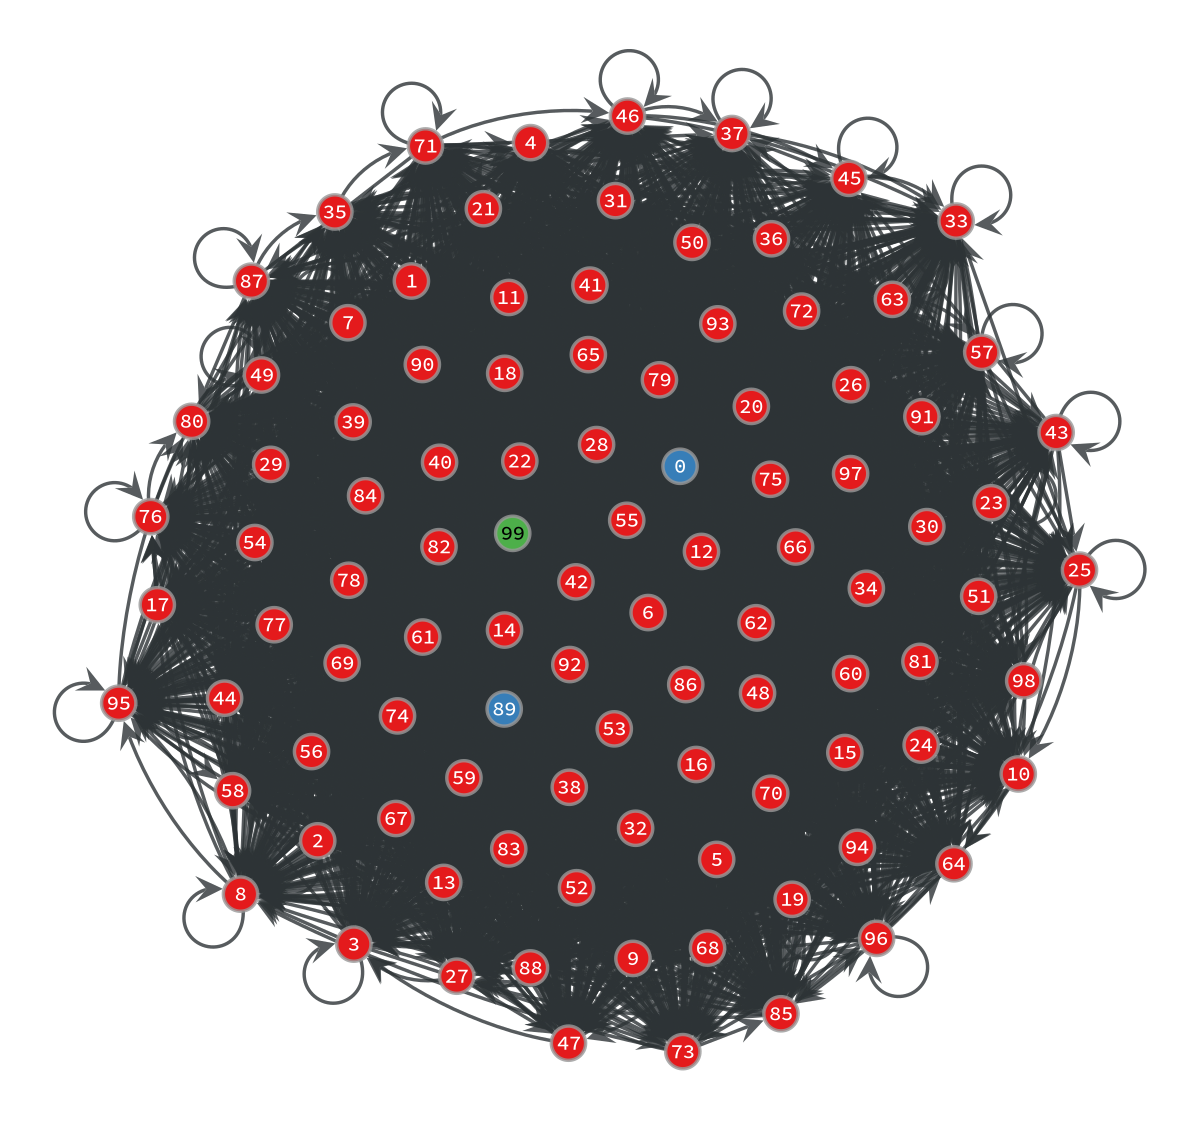

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7f3ab6230230, at 0x7f3ab623b310>

In [10]:
graph = s[1].G

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1
highlight[graph.vertex((par['L'] - 1) * par['L']-1)] = 1
highlight[graph.vertex(graph.num_vertices()-1)] = 2

graph_draw(
    graph,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    vcmap=plt.cm.Set1
)

In [11]:
print(f'Links density:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Links density:0.4842


In [12]:
for input in par['input_set']:
    output,_ = m.ff(input,s[0],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Input:[-2, -2] -> Output:10.0
Input:[-2, 2] -> Output:-10.0
Input:[2, -2] -> Output:-10.0
Input:[2, 2] -> Output:-10.0


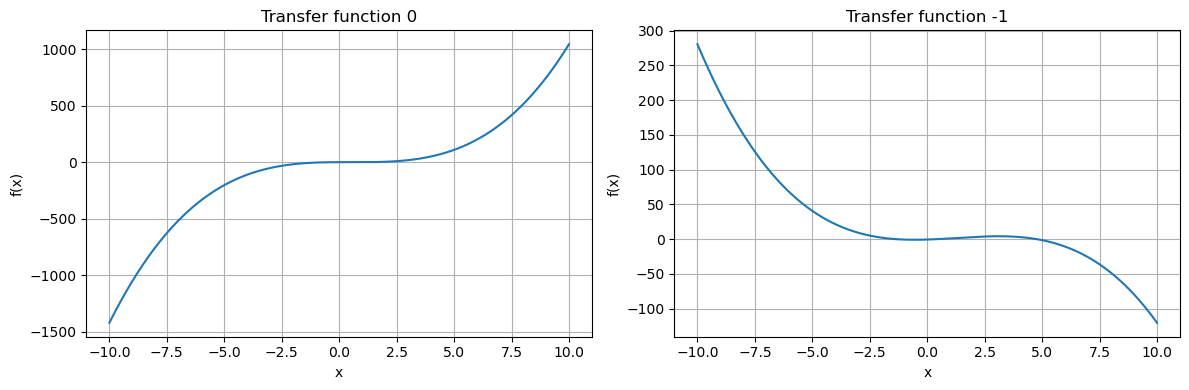

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in (0,-1):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

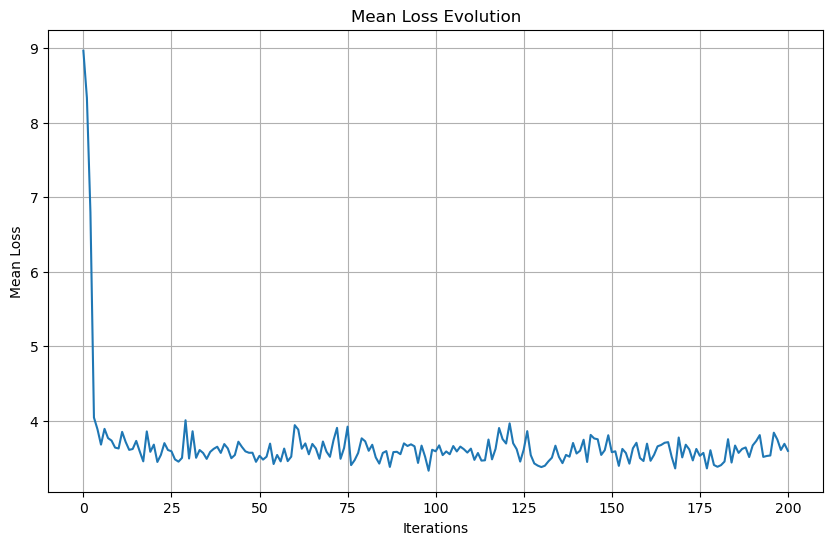

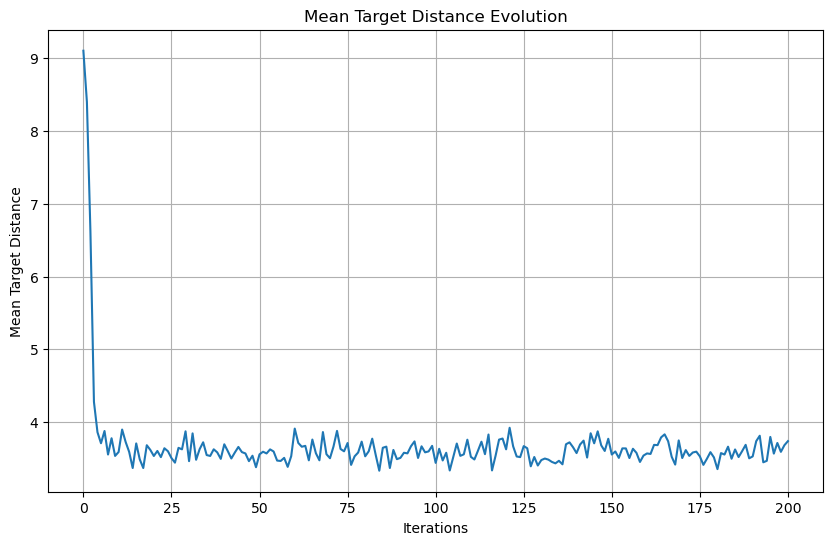

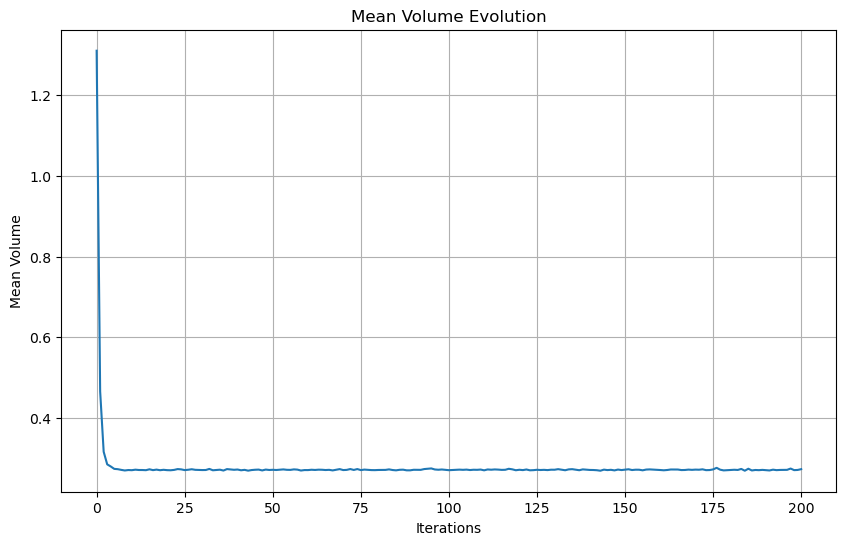

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()